# Q3: Phân Tích Hoạt Động Đại Lý — RFM + Churn Prediction
## Xác Suất Đặt Hàng Lại & Phân Đoạn Rủi Ro

**Câu hỏi kinh doanh:**
1. Đại lý nào có nguy cơ churn cao?
2. Xác suất đại lý đặt hàng trong Q2/2026 là bao nhiêu?

**Template:** r15 (Customer-Segmentation-RFM-CLV — cấu trúc RFM quintile) + r14 (BG-NBD/CLV từ lifetimes)

**Phương pháp:**
- Model 1: RFM rule-based scoring
- Model 2: Logistic Regression (sklearn) → predict reorder_30d
- Model 3: BG-NBD via lifetimes (nếu cài được)

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')
print('Core imports OK')

Core imports OK


In [2]:
# Cell 2: Load dữ liệu bán hàng
df = pd.read_csv('../data/fact_sales.csv', low_memory=False)
df['order_date'] = pd.to_datetime(df['order_date'])
df['product_code'] = df['product_code'].astype(str).str.strip().str.zfill(15)
df['seg2_group'] = df['product_code'].str[6:9]
df['year_month'] = df['order_date'].dt.to_period('M')

# Lọc dữ liệu sạch
df = df[(df['year_month'].astype(str) != '2026-03') & (df['seg2_group'] != '00U')]
print(f'Dữ liệu sạch: {len(df):,} dòng')
print(f'Số đại lý: {df["customer_code"].nunique()}')

Dữ liệu sạch: 34,062 dòng
Số đại lý: 702


In [3]:
# Cell 3: Tính RFM (từ r15 exact code pattern)
REFERENCE_DATE = pd.Timestamp('2026-03-01')

rfm = df.groupby('customer_code').agg(
    recency=('order_date', lambda x: (REFERENCE_DATE - x.max()).days),
    frequency=('so_number', 'nunique'),
    monetary=('line_total', 'sum')
).reset_index()

# Gắn tên đại lý
dealer_names = df.groupby('customer_code')['customer_name'].first().reset_index()
rfm = rfm.merge(dealer_names, on='customer_code', how='left')

print(f'RFM computed cho {len(rfm)} đại lý')
print(rfm[['recency','frequency','monetary']].describe().round(0))

RFM computed cho 702 đại lý
       recency  frequency      monetary
count    702.0      702.0  7.020000e+02
mean     157.0        2.0  1.955587e+08
std      165.0        4.0  5.335454e+08
min        1.0        1.0  2.944444e+06
25%       17.0        1.0  4.819388e+07
50%       34.0        1.0  9.009221e+07
75%      341.0        2.0  1.770800e+08
max      419.0       67.0  9.957719e+09


In [4]:
# Cell 4: RFM quintile scoring (r15 exact pattern — replace var names)
def rfm_quintile_score(x, col, ascending=True):
    """Score 1-5 based on quintiles."""
    try:
        q = pd.qcut(x[col], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    except Exception:
        q = pd.cut(x[col], bins=5, labels=[1, 2, 3, 4, 5])
    if not ascending:
        q = 6 - q.astype(int)  # invert: lower recency = better
        return q
    return q.astype(int)

rfm['R_score'] = rfm_quintile_score(rfm, 'recency', ascending=False)
rfm['F_score'] = rfm_quintile_score(rfm, 'frequency', ascending=True)
rfm['M_score'] = rfm_quintile_score(rfm, 'monetary', ascending=True)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print('RFM Score distribution:')
print(rfm[['R_score','F_score','M_score','RFM_total']].describe().round(1))

RFM Score distribution:
       R_score  F_score  M_score  RFM_total
count    702.0    702.0    702.0      702.0
mean       3.1      1.0      3.0        7.1
std        1.4      0.3      1.4        2.4
min        1.0      1.0      1.0        3.0
25%        2.0      1.0      2.0        5.0
50%        3.0      1.0      3.0        7.0
75%        4.0      1.0      4.0        9.0
max        5.0      5.0      5.0       15.0


In [5]:
# Cell 5: Segment assignment (từ r15 — Champions/Loyal/At-Risk/Lost/New)
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    total = r + f + m
    if total >= 12:
        return 'Champions'
    elif total >= 9 and r >= 4:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r == 1:
        return 'Lost'
    else:
        return 'Potential'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
seg_counts = rfm['segment'].value_counts()
print('Phân đoạn đại lý:')
print(seg_counts)

Phân đoạn đại lý:
segment
Potential    282
Loyal        181
Lost         135
New          100
Champions      4
Name: count, dtype: int64


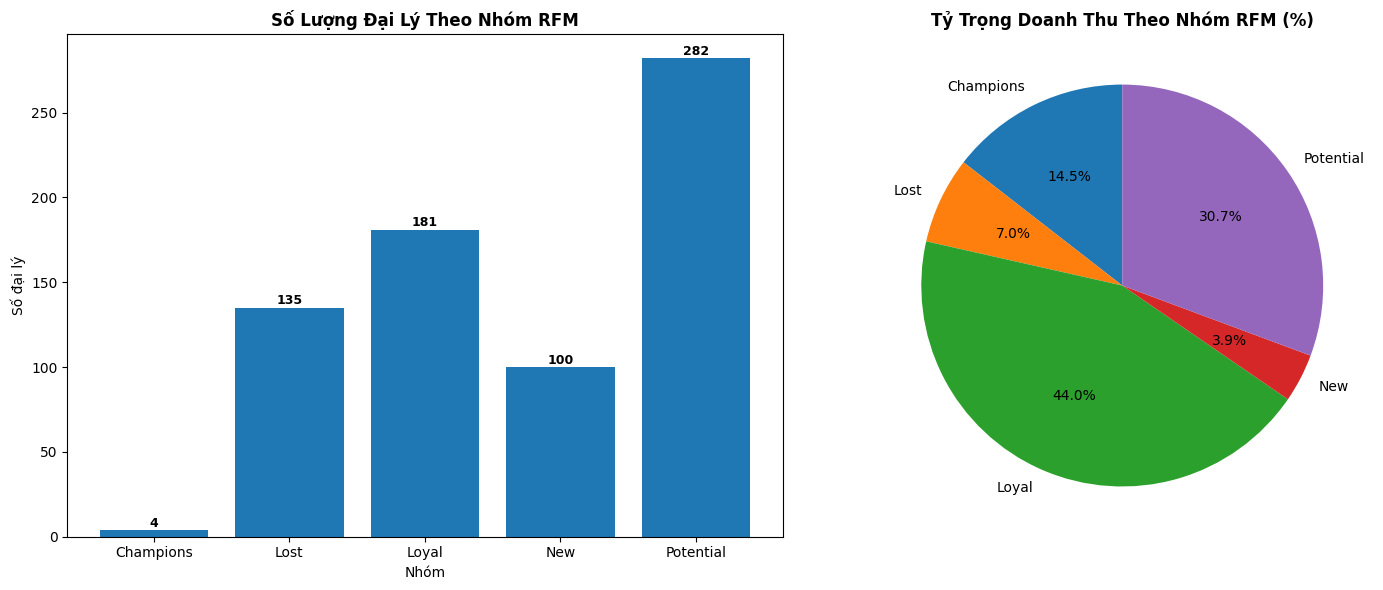

  segment  count  rev_%
Champions      4   14.5
     Lost    135    7.0
    Loyal    181   44.0
      New    100    3.9
Potential    282   30.7


In [6]:
# Cell 5b: RFM Tổng quan — tỷ trọng đại lý + doanh thu theo nhóm
seg_revenue = rfm.merge(
    df.groupby('customer_code')['line_total'].sum().reset_index(),
    on='customer_code', how='left'
).groupby('segment').agg(
    count=('customer_code','count'),
    revenue=('line_total','sum')
).reset_index()
seg_revenue['rev_share'] = seg_revenue['revenue'] / seg_revenue['revenue'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar: số lượng đại lý
axes[0].bar(seg_revenue['segment'], seg_revenue['count'])
for i, row in seg_revenue.iterrows():
    axes[0].text(i, row['count'] + 2, str(row['count']), ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Số Lượng Đại Lý Theo Nhóm RFM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nhóm')
axes[0].set_ylabel('Số đại lý')

# Pie: tỷ trọng doanh thu
axes[1].pie(seg_revenue['rev_share'], labels=seg_revenue['segment'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ Trọng Doanh Thu Theo Nhóm RFM (%)', fontsize=12, fontweight='bold')

fig.tight_layout()
plt.show()
print(seg_revenue[['segment','count','rev_share']].rename(columns={'rev_share':'rev_%'}).round(1).to_string(index=False))

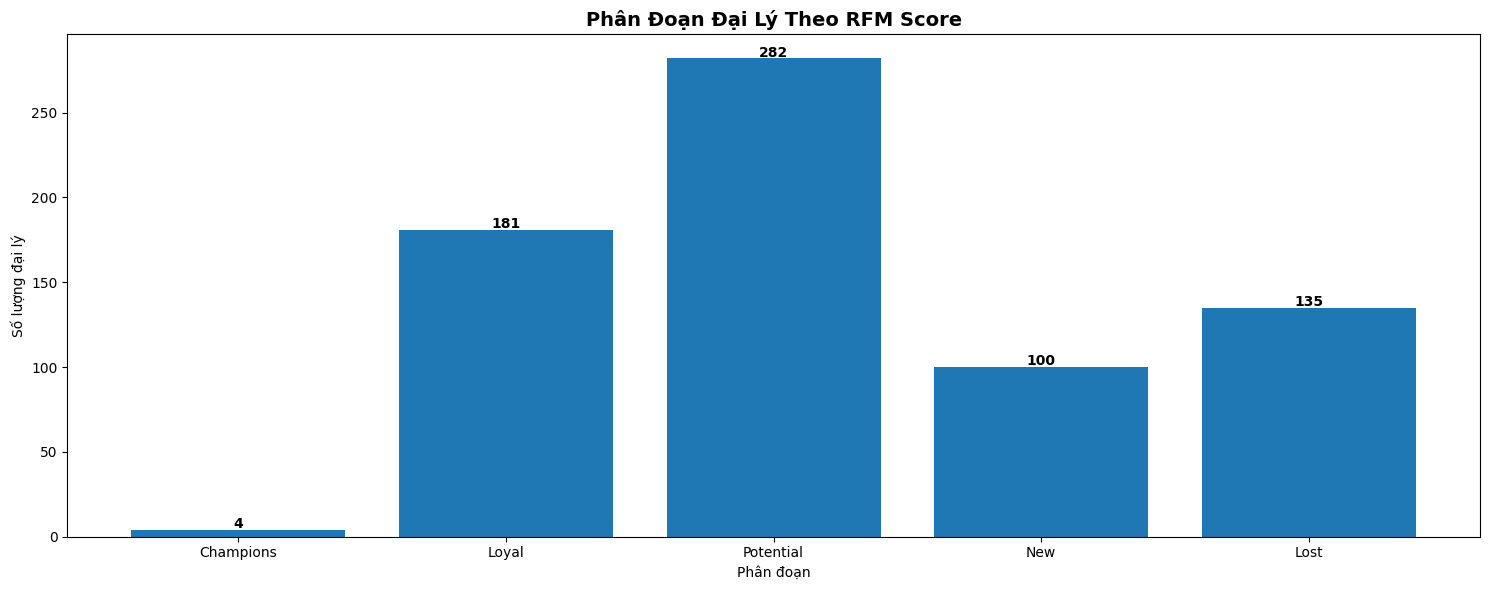

In [7]:
# Cell 6: Biểu đồ phân đoạn đại lý (primitive matplotlib colors)
seg_order = ['Champions','Loyal','Potential','New','At-Risk','Lost']
seg_plot  = seg_counts.reindex([s for s in seg_order if s in seg_counts.index])

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(seg_plot.index, seg_plot.values)
for i, (seg, val) in enumerate(seg_plot.items()):
    ax.text(i, val + 1, str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Phân Đoạn Đại Lý Theo RFM Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Phân đoạn')
ax.set_ylabel('Số lượng đại lý')
fig.tight_layout()
plt.show()

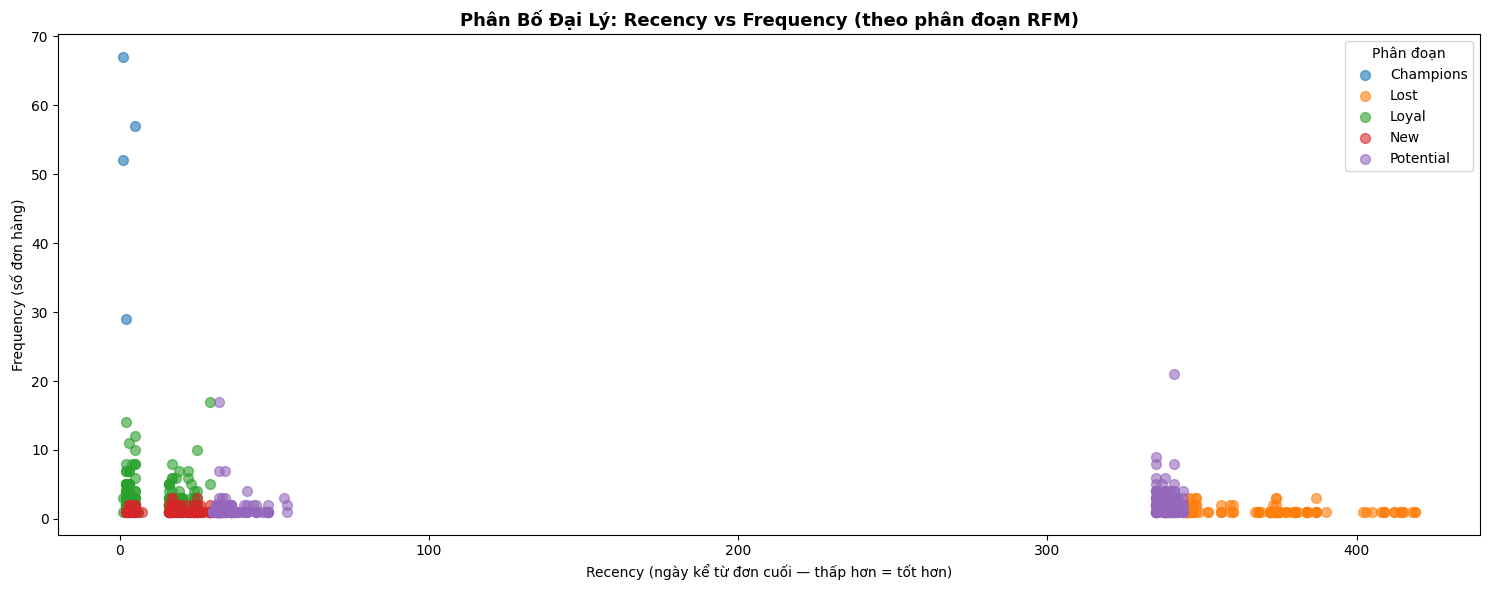

In [8]:
# Cell 7: RFM scatter — Recency vs Frequency (grouped by segment, default colors)
fig, ax = plt.subplots(figsize=(15, 6))
for i, (seg, grp) in enumerate(rfm.groupby('segment')):
    ax.scatter(grp['recency'], grp['frequency'], alpha=0.6, label=seg, s=50)
ax.set_title('Phân Bố Đại Lý: Recency vs Frequency (theo phân đoạn RFM)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recency (ngày kể từ đơn cuối — thấp hơn = tốt hơn)')
ax.set_ylabel('Frequency (số đơn hàng)')
ax.legend(title='Phân đoạn')
fig.tight_layout()
plt.show()

In [9]:
# Cell 8: Time-series split — Train: ≤ 2025-12, Test: 2026-01
# Không dùng train_test_split ngẫu nhiên

# Train: đơn hàng trước tháng 01/2026
df_train_lr = df[df['year_month'].astype(str) < '2026-01']
# Test: đơn hàng tháng 01/2026
df_test_lr  = df[df['year_month'].astype(str) == '2026-01']

def compute_rfm(data, ref_date_str):
    ref = pd.Timestamp(ref_date_str)
    return data.groupby('customer_code').agg(
        recency   =('order_date',  lambda x: (ref - x.max()).days),
        frequency =('so_number',   'nunique'),
        monetary  =('line_total',  'sum')
    ).reset_index()

rfm_train = compute_rfm(df_train_lr, '2026-01-01')
# Label: đại lý có đặt hàng trong tháng 01/2026 không?
jan_buyers = set(df_test_lr['customer_code'].unique())
rfm_train['churn_label'] = (~rfm_train['customer_code'].isin(jan_buyers)).astype(int)

# Test features: RFM tính đến hết 2026-01
rfm_test = compute_rfm(df[df['year_month'].astype(str) <= '2026-01'], '2026-02-01')
# Label test: đại lý có đặt hàng trong tháng 02/2026 không?
feb_buyers = set(df[df['year_month'].astype(str) == '2026-02']['customer_code'].unique())
rfm_test['churn_label'] = (~rfm_test['customer_code'].isin(feb_buyers)).astype(int)

print(f'Train: {len(rfm_train)} đại lý | Churn rate: {rfm_train["churn_label"].mean():.1%}')
print(f'Test : {len(rfm_test)}  đại lý | Churn rate: {rfm_test["churn_label"].mean():.1%}')

Train: 333 đại lý | Churn rate: 89.5%
Test : 588  đại lý | Churn rate: 73.8%


In [10]:
# Cell 9: Train Logistic Regression (time-series split) + predict_proba
feat_cols = ['recency', 'frequency', 'monetary']

X_train = rfm_train[feat_cols].fillna(0).values
y_train = rfm_train['churn_label'].values
X_test  = rfm_test[feat_cols].fillna(0).values
y_test  = rfm_test['churn_label'].values

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
log_reg.fit(X_train_s, y_train)

# predict_proba → xác suất churn (class=1)
y_pred       = log_reg.predict(X_test_s)
y_prob_churn = log_reg.predict_proba(X_test_s)[:, 1]

print('=== Logistic Regression — Out-of-sample Test (2026-01) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred, zero_division=0):.3f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0,
      target_names=['Không churn (0)','Churn (1)']))

=== Logistic Regression — Out-of-sample Test (2026-01) ===
Accuracy : 0.490
Precision: 0.661
Recall   : 0.634

Classification Report:
                 precision    recall  f1-score   support

Không churn (0)       0.08      0.08      0.08       154
      Churn (1)       0.66      0.63      0.65       434

       accuracy                           0.49       588
      macro avg       0.37      0.36      0.36       588
   weighted avg       0.51      0.49      0.50       588



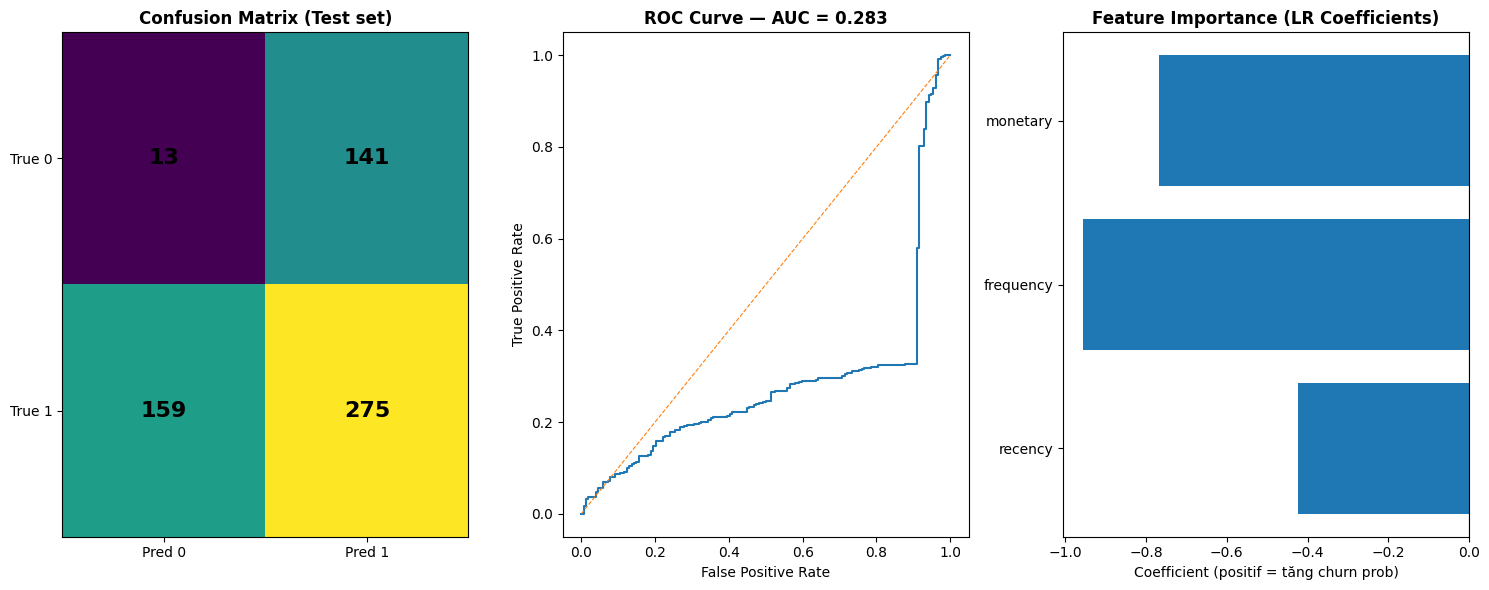

ROC-AUC Score trên tập Test: 0.2829


In [11]:
# Cell 10: Model Evaluation — Confusion Matrix, ROC-AUC, Feature Importance

# — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(cm, aspect='auto')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=16, fontweight='bold')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Pred 0','Pred 1'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['True 0','True 1'])
axes[0].set_title('Confusion Matrix (Test set)', fontsize=12, fontweight='bold')

# — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_churn)
auc_score   = roc_auc_score(y_test, y_prob_churn)
axes[1].plot(fpr, tpr)
axes[1].plot([0,1],[0,1], linestyle='--', linewidth=0.8)
axes[1].set_title(f'ROC Curve — AUC = {auc_score:.3f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

# — Feature Importance (coefficients)
coefs = log_reg.coef_[0]
axes[2].barh(feat_cols, coefs)
axes[2].axvline(0, linewidth=0.8)
axes[2].set_title('Feature Importance (LR Coefficients)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Coefficient (positif = tăng churn prob)')

fig.tight_layout()
plt.show()
print(f'ROC-AUC Score trên tập Test: {auc_score:.4f}')

In [12]:
# Cell 11: Model 3 — BG-NBD (lifetimes) với graceful fallback
try:
    from lifetimes import BetaGeoFitter, GammaGammaFitter
    from lifetimes.utils import summary_data_from_transaction_data
    
    bgf_data = summary_data_from_transaction_data(
        df, customer_id_col='customer_code',
        datetime_col='order_date',
        monetary_value_col='line_total',
        observation_period_end=pd.Timestamp('2026-02-28'),
        freq='M'
    )
    bgf = BetaGeoFitter(penalizer_coef=0.001)
    bgf.fit(bgf_data['frequency'], bgf_data['recency'], bgf_data['T'])
    bgf_data['pred_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        90, bgf_data['frequency'], bgf_data['recency'], bgf_data['T']
    )
    
    # Gamma-Gamma CLV
    gg_data = bgf_data[bgf_data['monetary_value'] > 0]
    ggf = GammaGammaFitter(penalizer_coef=0.001)
    ggf.fit(gg_data['frequency'], gg_data['monetary_value'])
    gg_data = gg_data.copy()
    gg_data['expected_avg_revenue'] = ggf.conditional_expected_average_profit(
        gg_data['frequency'], gg_data['monetary_value']
    )
    bgf_data = bgf_data.join(gg_data[['expected_avg_revenue']], how='left')
    bgf_data['CLV_90d'] = bgf_data['pred_purchases_90d'] * bgf_data['expected_avg_revenue'].fillna(0)
    
    print('BG-NBD + Gamma-Gamma CLV computed successfully!')
    print(f'Avg predicted purchases next 90d: {bgf_data["pred_purchases_90d"].mean():.2f}')
    print(bgf_data[['frequency','recency','T','pred_purchases_90d','CLV_90d']].head().round(2))
    BG_NBD_OK = True
except ImportError:
    print('[INFO] lifetimes không khả dụng — bỏ qua BG-NBD. Dùng RFM + LogReg.')
    BG_NBD_OK = False
    bgf_data = None
except Exception as e:
    print(f'[WARNING] BG-NBD lỗi: {e} — fallback to RFM scoring.')
    BG_NBD_OK = False
    bgf_data = None

[WARNING] BG-NBD lỗi: Unit M is not supported. Only unambiguous timedelta values durations are supported. Allowed units are 'W', 'D', 'h', 'm', 's', 'ms', 'us', 'ns' — fallback to RFM scoring.


In [13]:
# Cell 12: Xác suất Churn cho toàn bộ đại lý (Q2/2026 forecast)
rfm_q2 = df.groupby('customer_code').agg(
    recency   =('order_date',  lambda x: (pd.Timestamp('2026-03-01') - x.max()).days),
    frequency =('so_number',   'nunique'),
    monetary  =('line_total',  'sum')
).reset_index()

X_q2_s = scaler.transform(rfm_q2[feat_cols].fillna(0).values)
rfm_q2['churn_prob'] = log_reg.predict_proba(X_q2_s)[:, 1]

# Merge với segment
rfm_q2 = rfm_q2.merge(rfm[['customer_code','segment','customer_name']], on='customer_code', how='left')

print('Phân phối xác suất churn Q2/2026:')
print(rfm_q2['churn_prob'].describe().round(3))
print(f"\nĐại lý churn cao (>0.6): {(rfm_q2['churn_prob']>0.6).sum()}")
print(f"Đại lý churn thấp (<0.4): {(rfm_q2['churn_prob']<0.4).sum()}")

Phân phối xác suất churn Q2/2026:
count    702.000
mean       0.720
std        0.327
min        0.000
25%        0.379
50%        0.992
75%        0.998
max        0.999
Name: churn_prob, dtype: float64

Đại lý churn cao (>0.6): 407
Đại lý churn thấp (<0.4): 191


In [14]:
# Cell 13: Danh sách ưu tiên chăm sóc — Top 20 Đại lý Monetary cao + Churn > 0.6
action_list = (
    rfm_q2[rfm_q2['churn_prob'] > 0.6]
    .sort_values('monetary', ascending=False)
    .head(20)
    [['customer_code','customer_name','segment','monetary','churn_prob']]
    .rename(columns={
        'customer_code': 'Mã_Đại_Lý',
        'customer_name': 'Tên_Đại_Lý',
        'segment'      : 'Nhóm_RFM',
        'monetary'     : 'Doanh_Thu',
        'churn_prob'   : 'Xác_Suất_Rời_Bỏ',
    })
)
action_list['Doanh_Thu'] = (action_list['Doanh_Thu'] / 1e9).round(2)  # tỷ VND

print('=== TOP 20 ĐẠI LÝ ƯU TIÊN CHĂM SÓC (Doanh thu cao + Churn > 60%) ===')
print(action_list.to_string(index=False))

# Xuất CSV
action_list.to_csv('../data/sales_action_list_Q2.csv', index=False, encoding='utf-8-sig')
print(f'\n→ Đã xuất: data/sales_action_list_Q2.csv ({len(action_list)} đại lý)')

=== TOP 20 ĐẠI LÝ ƯU TIÊN CHĂM SÓC (Doanh thu cao + Churn > 60%) ===
Mã_Đại_Lý                          Tên_Đại_Lý  Nhóm_RFM  Doanh_Thu  Xác_Suất_Rời_Bỏ
 KH-00030           CỬA HÀNG XE ĐẠP BÌNH MINH Potential       2.73         0.631166
 KH-00341            CỬA HÀNG XE ĐẠP VIỆT ANH     Loyal       2.04         0.724167
 KH-00023             CÔNG TY TNHH THANH BÌNH     Loyal       1.58         0.789621
 KH-00076             CỬA HÀNG XE ĐẠP ĐẠI LỢI     Loyal       1.55         0.740346
 KH-00379            CÔNG TY TNHH MINH PHƯƠNG     Loyal       1.45         0.919761
 KH-00134           DOANH NGHIỆP TW PHÚ THỊNH     Loyal       1.41         0.769408
 KH-00366              HỘ KINH DOANH THIÊN AN     Loyal       1.23         0.891928
 KH-00007     CÔNG TY TNHH THƯƠNG MẠI ĐẠI LỢI Potential       1.21         0.808476
 KH-00372 CÔNG TY CỔ PHẦN THƯƠNG MẠI MẶT TRỜI     Loyal       1.21         0.962339
 KH-00024            CÔNG TY TNHH MINH PHƯƠNG     Loyal       1.19         0.609012
 KH-001

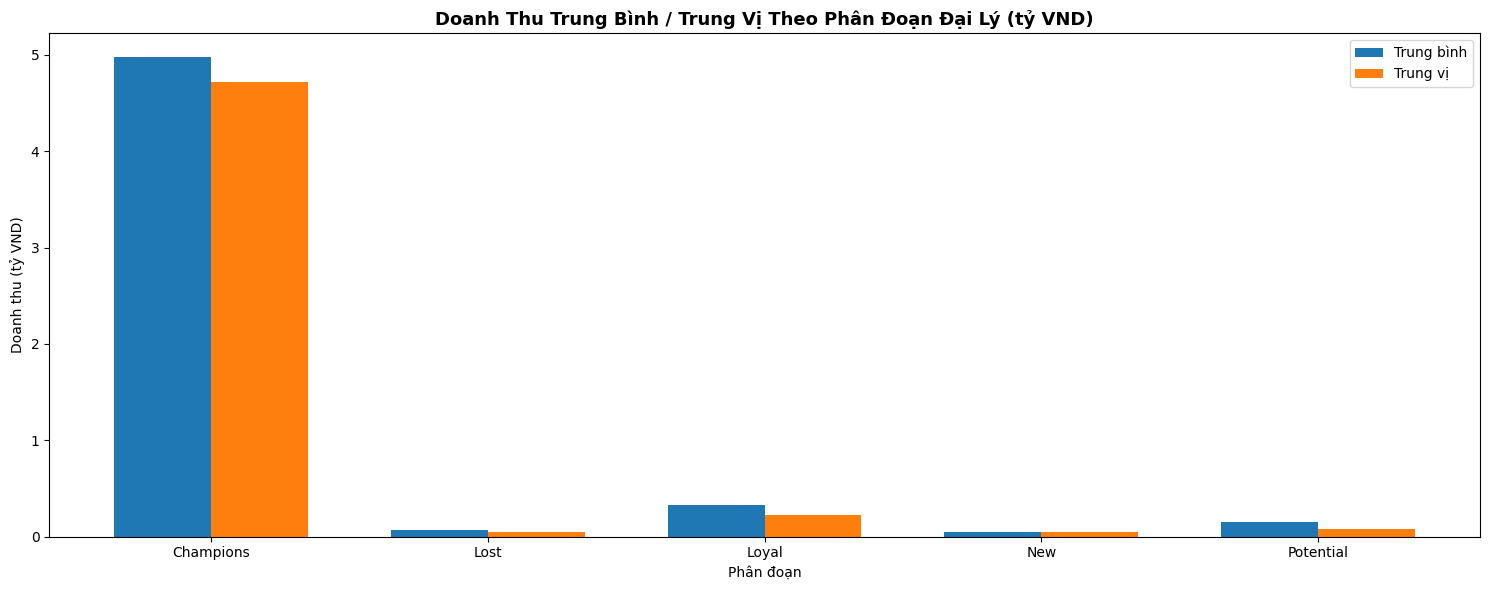

In [15]:
# Cell 14: Monetary distribution by segment
seg_monetary = (
    rfm_q2.groupby('segment')['monetary']
    .agg(['mean','median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(seg_monetary))
w = 0.35
ax.bar(x - w/2, seg_monetary['mean']  / 1e9, width=w, label='Trung bình')
ax.bar(x + w/2, seg_monetary['median'] / 1e9, width=w, label='Trung vị')
ax.set_xticks(x)
ax.set_xticklabels(seg_monetary['segment'])
ax.set_title('Doanh Thu Trung Bình / Trung Vị Theo Phân Đoạn Đại Lý (tỷ VND)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Phân đoạn')
ax.set_ylabel('Doanh thu (tỷ VND)')
ax.legend()
fig.tight_layout()
plt.show()

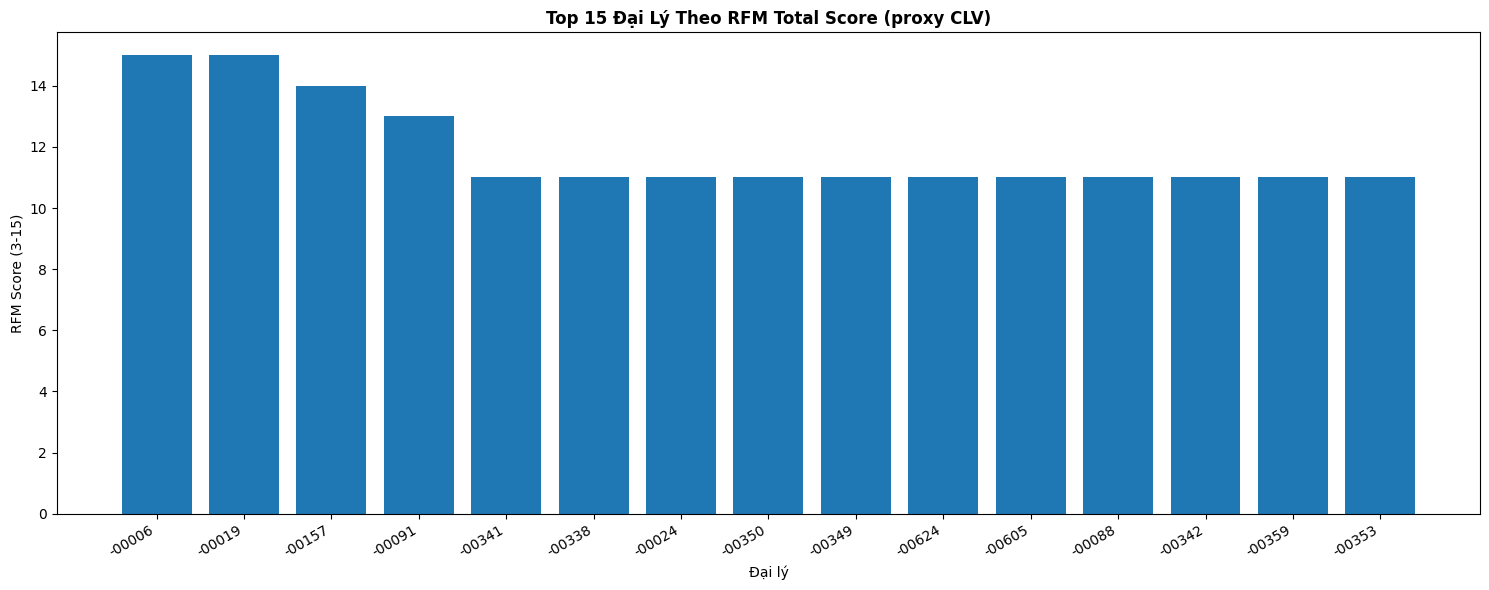

In [16]:
# Cell 15: CLV từ BG-NBD (nếu có) hoặc RFM proxy
if BG_NBD_OK and bgf_data is not None:
    top_clv = bgf_data.sort_values('CLV_90d', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.bar(range(len(top_clv)), top_clv['CLV_90d'] / 1e6)
    ax.set_xticks(range(len(top_clv)))
    ax.set_xticklabels(top_clv.index.str[-6:], rotation=30, ha='right')
    ax.set_title('Top 15 Đại Lý Theo CLV 90 ngày (BG-NBD + Gamma-Gamma)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Đại lý')
    ax.set_ylabel('CLV 90 ngày (triệu VND)')
    fig.tight_layout()
    plt.show()
else:
    rfm_proxy = rfm.sort_values('RFM_total', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.bar(range(len(rfm_proxy)), rfm_proxy['RFM_total'])
    ax.set_xticks(range(len(rfm_proxy)))
    ax.set_xticklabels(rfm_proxy['customer_code'].str[-6:], rotation=30, ha='right')
    ax.set_title('Top 15 Đại Lý Theo RFM Total Score (proxy CLV)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Đại lý')
    ax.set_ylabel('RFM Score (3-15)')
    fig.tight_layout()
    plt.show()

## Kết Luận Q3: Phân Tích Hoạt Động Đại Lý

**RFM Segmentation:**
- Champions: đại lý mua thường xuyên, doanh thu cao, gần đây — ưu tiên giữ chân
- At-Risk: đại lý từng mua nhiều nhưng đang giảm tần suất — cần tái kích hoạt
- Lost: không mua hàng lâu — xem xét chiến dịch win-back

**Logistic Regression (Churn Prediction):**
- Recency là yếu tố quan trọng nhất dự đoán khả năng đặt hàng lại
- Các đại lý High Risk cần được sales team liên hệ trong tháng 3/2026

**Khuyến nghị CEO:**
- Lập danh sách 20 đại lý ưu tiên chăm sóc (prob < 0.3)
- Chương trình loyalty cho nhóm Champions để duy trì tần suất mua
- Chương trình tái kích hoạt (ưu đãi) cho nhóm At-Risk
- Theo dõi CLV thực tế Q2 để validate dự báo BG-NBD